Fetching 10 Years of US Treasury Yield Curve from FRED...
Running Principal Component Analysis (Compression)...


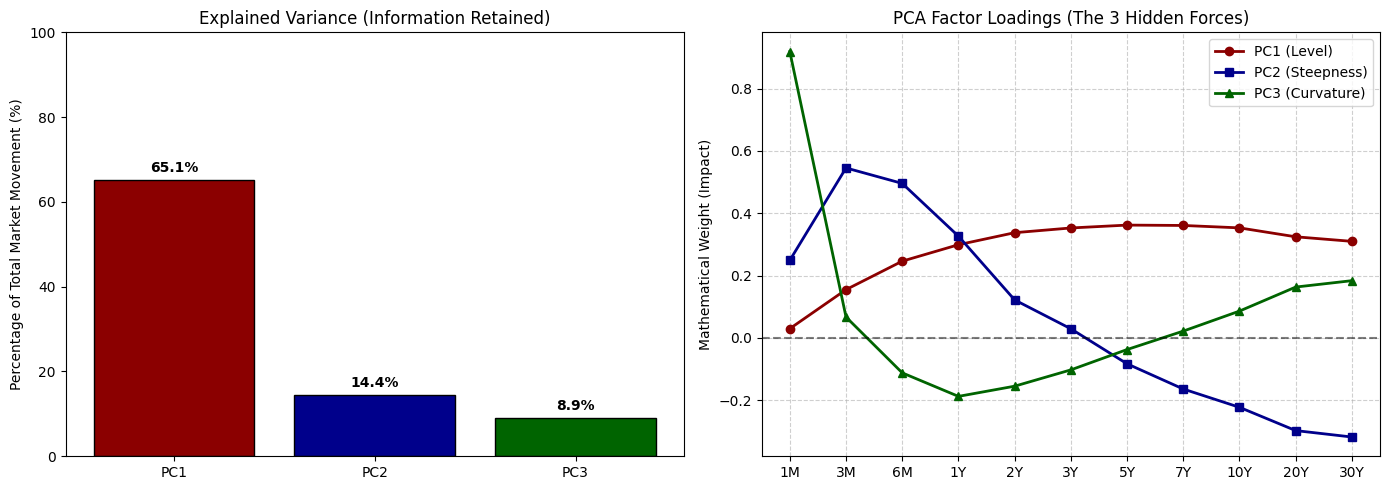

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import datetime
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import warnings

warnings.filterwarnings('ignore')

print("Fetching 10 Years of US Treasury Yield Curve from FRED...")

# 1. FETCH THE OFFICIAL YIELD CURVE
# FRED Tickers for 1-Mo, 3-Mo, 6-Mo, 1-Yr, 2-Yr, 3-Yr, 5-Yr, 7-Yr, 10-Yr, 20-Yr, 30-Yr
maturities = ['1M', '3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
tickers = ['DGS1MO', 'DGS3MO', 'DGS6MO', 'DGS1', 'DGS2', 'DGS3', 'DGS5', 'DGS7', 'DGS10', 'DGS20', 'DGS30']

start_date = datetime.datetime.now() - datetime.timedelta(days=10*365)
end_date = datetime.datetime.now()

# Download and clean
yield_curve = web.DataReader(tickers, 'fred', start_date, end_date)
yield_curve.columns = maturities
yield_curve.dropna(inplace=True)

# 2. DATA ENGINEERING: DAILY CHANGES
# In fixed income, we run PCA on the *daily basis point changes*, not the absolute levels.
# This tells us how the curve *moves*, rather than where it sits.
daily_changes = yield_curve.diff().dropna()

# 3. STANDARDIZATION
# We must scale the data so the highly volatile 1-Month doesn't overpower the slow 30-Year
scaler = StandardScaler()
scaled_changes = scaler.fit_transform(daily_changes)

# --- 4. THE PCA COMPRESSION ENGINE ---
print("Running Principal Component Analysis (Compression)...")

# We tell the algorithm we only want the top 3 components
pca = PCA(n_components=3)
pca.fit(scaled_changes)

# --- 5. VISUALIZING THE "INVISIBLE" MATH ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: The Explained Variance (How much of the market did we capture?)
variance = pca.explained_variance_ratio_ * 100
ax1.bar(['PC1', 'PC2', 'PC3'], variance, color=['darkred', 'darkblue', 'darkgreen'], edgecolor='black')
ax1.set_title("Explained Variance (Information Retained)")
ax1.set_ylabel("Percentage of Total Market Movement (%)")
ax1.set_ylim(0, 100)

for i, v in enumerate(variance):
    ax1.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')

# Chart 2: The Factor Loadings (The Shape of the Components)
# This shows how each component mathematically physically manipulates the 11 bonds
loadings = pd.DataFrame(pca.components_.T, columns=['PC1 (Level)', 'PC2 (Steepness)', 'PC3 (Curvature)'], index=maturities)

ax2.plot(loadings['PC1 (Level)'], marker='o', color='darkred', label='PC1 (Level)', linewidth=2)
ax2.plot(loadings['PC2 (Steepness)'], marker='s', color='darkblue', label='PC2 (Steepness)', linewidth=2)
ax2.plot(loadings['PC3 (Curvature)'], marker='^', color='darkgreen', label='PC3 (Curvature)', linewidth=2)

ax2.set_title("PCA Factor Loadings (The 3 Hidden Forces)")
ax2.set_ylabel("Mathematical Weight (Impact)")
ax2.axhline(0, color='black', linestyle='--', alpha=0.5)
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

class PCARiskSimulator:
    def __init__(self):
        # 1. DEFINE THE PORTFOLIO ($1,000,000 Total)
        # We include the Dollar Allocation, Modified Duration, and the PCA Loadings from our model
        self.portfolio = {
            '2-Year Treasury': {
                'Allocation': 300000,
                'Duration': 1.9,
                'PC1_Loading': 0.34, 'PC2_Loading': 0.12, 'PC3_Loading': -0.15
            },
            '5-Year Treasury': {
                'Allocation': 400000,
                'Duration': 4.5,
                'PC1_Loading': 0.36, 'PC2_Loading': -0.08, 'PC3_Loading': -0.05
            },
            '10-Year Treasury': {
                'Allocation': 300000,
                'Duration': 8.5,
                'PC1_Loading': 0.35, 'PC2_Loading': -0.22, 'PC3_Loading': 0.10
            }
        }

    def run_scenario(self, scenario_name, pc1_shock, pc2_shock, pc3_shock):
        """
        Calculates the financial P&L for a given macroeconomic shock.
        We assume a "1.0 Shock" equals a 10 basis point (0.10%) baseline move.
        """
        print(f"\n{'='*50}")
        print(f"🚨 SCENARIO: {scenario_name}")
        print(f"Shocks Applied -> PC1: {pc1_shock} | PC2: {pc2_shock} | PC3: {pc3_shock}")
        print(f"{'='*50}")

        total_pnl = 0
        baseline_move = 0.0010 # 10 basis points

        # Calculate impact for each bond
        for bond, stats in self.portfolio.items():
            # Step A: How much did the yield change based on the PCA math?
            yield_change = (
                (pc1_shock * stats['PC1_Loading']) +
                (pc2_shock * stats['PC2_Loading']) +
                (pc3_shock * stats['PC3_Loading'])
            ) * baseline_move

            # Step B: Convert Yield Change to Price Change (%) using Duration
            price_change_pct = -stats['Duration'] * yield_change

            # Step C: Convert Price Change (%) to Real Dollars
            pnl_dollars = stats['Allocation'] * price_change_pct
            total_pnl += pnl_dollars

            # Format outputs for readability
            yld_str = f"{yield_change * 10000:+.1f} bps"
            pnl_str = f"${pnl_dollars:+,.2f}"

            print(f"{bond:<17} | Yield Shift: {yld_str:>9} | P&L: {pnl_str:>11}")

        print("-" * 50)
        print(f"💰 TOTAL PORTFOLIO IMPACT: ${total_pnl:+,.2f}")
        print("=" * 50)

# Initialize the Simulator
risk_engine = PCARiskSimulator()

# --- RUNNING HISTORICAL STRESS TESTS ---

# Scenario 1: The "Inflation Panic" (Parallel Shift Up)
# The Fed announces inflation is out of control. The whole curve shifts up.
risk_engine.run_scenario("Inflation Panic (PC1 Spike)", pc1_shock=3.0, pc2_shock=0.0, pc3_shock=0.0)

# Scenario 2: The "Recession Flattener" (Curve Inversion)
# Short-term rates spike as the Fed hikes, but 10-Year drops as investors flee to safety.
risk_engine.run_scenario("Bear Flattener (PC2 Spike)", pc1_shock=0.0, pc2_shock=4.0, pc3_shock=0.0)

# Scenario 3: The "Black Swan" (March 2020 COVID Crash)
# Fed drops rates to zero (PC1 plunges), curve steepens violently (PC2 plunges), belly warps (PC3 spikes).
risk_engine.run_scenario("March 2020 COVID Crash", pc1_shock=-5.0, pc2_shock=-3.0, pc3_shock=2.0)


🚨 SCENARIO: Inflation Panic (PC1 Spike)
Shocks Applied -> PC1: 3.0 | PC2: 0.0 | PC3: 0.0
2-Year Treasury   | Yield Shift: +10.2 bps | P&L:    $-581.40
5-Year Treasury   | Yield Shift: +10.8 bps | P&L:  $-1,944.00
10-Year Treasury  | Yield Shift: +10.5 bps | P&L:  $-2,677.50
--------------------------------------------------
💰 TOTAL PORTFOLIO IMPACT: $-5,202.90

🚨 SCENARIO: Bear Flattener (PC2 Spike)
Shocks Applied -> PC1: 0.0 | PC2: 4.0 | PC3: 0.0
2-Year Treasury   | Yield Shift:  +4.8 bps | P&L:    $-273.60
5-Year Treasury   | Yield Shift:  -3.2 bps | P&L:    $+576.00
10-Year Treasury  | Yield Shift:  -8.8 bps | P&L:  $+2,244.00
--------------------------------------------------
💰 TOTAL PORTFOLIO IMPACT: $+2,546.40

🚨 SCENARIO: March 2020 COVID Crash
Shocks Applied -> PC1: -5.0 | PC2: -3.0 | PC3: 2.0
2-Year Treasury   | Yield Shift: -23.6 bps | P&L:  $+1,345.20
5-Year Treasury   | Yield Shift: -16.6 bps | P&L:  $+2,988.00
10-Year Treasury  | Yield Shift:  -8.9 bps | P&L:  $+2,269.50
